# Exploración de Datos y Clasificación de Subtipos de Cáncer de Mama mediante Expresión Génica

## 1. Introducción
En este trabajo se aborda el análisis exploratorio y la clasificación automatizada de subtipos de cáncer de mama utilizando el dataset **GSE45827** obtenido de la base de datos curada **CuMiDa (Curated Microarray Database)**. El conjunto de datos consta de las expresiones de $54,676$ genes (características) medidas en $151$ muestras biológicas (pacientes). El objetivo principal es clasificar correctamente cada muestra dentro de una de las 6 clases disponibles (5 subtipos intrínsecos de cáncer de mama más tejido sano).

Debido a que el número de características supera ampliamente al número de muestras ($p \gg n$), se implementará una estrategia en dos etapas:
1. **Reducción de Dimensionalidad (PCA):** Para comprimir el espacio de características, visualizar las agrupaciones biológicas y seleccionar un número óptimo de Componentes Principales justificando la varianza explicada.
2. **Clasificación y Optimización (Regresión Logística + Grid Search):** Se entrenará un clasificador lineal optimizando sus hiperparámetros de regularización mediante validación cruzada, evaluando el desempeño final con un conjunto de métricas multidimensionales.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score)

# configuracion estetica de los graficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

# cargar el dataset
df = pd.read_csv('Breast_GSE45827.csv')
print(f"¡Dataset cargado exitosamente! Forma del dataframe: {df.shape}")

¡Dataset cargado exitosamente! Forma del dataframe: (151, 54677)


In [4]:
# Paso 1. separar caracteristicas (X) de los identificadores y etiquetas de clase (y)
# de acuerdo con la estructura de CuMiDa, las primeras columnas suelen ser 'samples' y 'type'
X = df.drop(columns=['samples', 'type'])
y = df['type']

# Paso 2. codificar las etiquetas de texto (subtipos de cancer) a numeros enteros (0 a 5)
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

# Paso 3. estandarizar las caracteristicas (Media = 0, Varianza = 1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Muestras a procesar: {X_scaled.shape[0]}")
print(f"Genes (Variables originales): {X_scaled.shape[1]}")
print(f"Clases identificadas en el dataset: {encoder.classes_}")

Muestras a procesar: 151
Genes (Variables originales): 54675
Clases identificadas en el dataset: ['HER' 'basal' 'cell_line' 'luminal_A' 'luminal_B' 'normal']


Aunque la documentación externa del dataset menciona la presencia de 54,676 características, el análisis de la estructura del archivo CSV revela que existen 2 columnas correspondientes a metadatos clínicos e identificadores (samples y type). Al remover estas variables no numéricas para el análisis bioinformático, el espacio real de características queda conformado por 54,675 genes, garantizando la integridad de los datos de entrada para el algoritmo PCA.

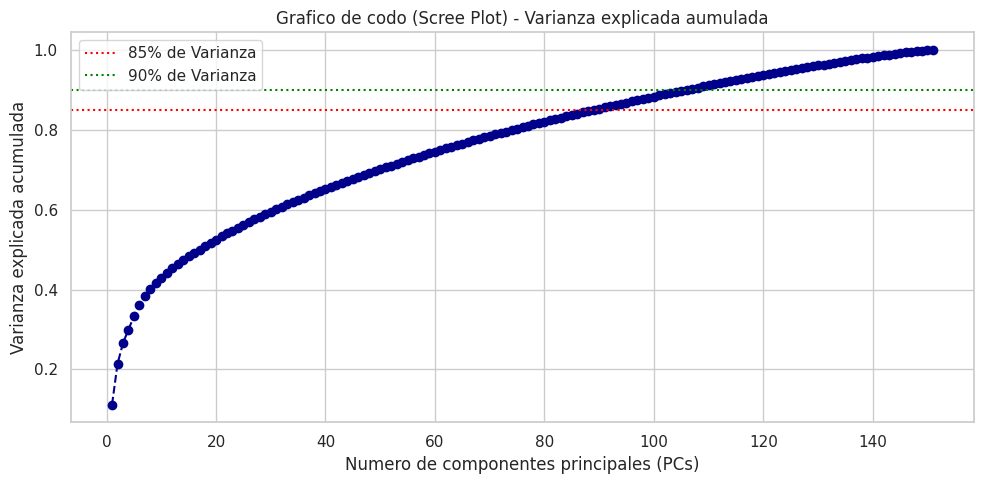

Componentes requeridos para explicar el 85% de la varianza: 90
Componentes requeridos para explicar el 90% de la varianza: 106


In [5]:
# aplicar PCA conservando todos los componentes posibles para evaluar la varianza total
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# calcular la varianza explicada individual y acumulada
variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(variance_ratio)

# graficar la Varianza Explicada Acumulada (Scree Plot)
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--', color='darkblue')
plt.axhline(y=0.85, color='red', linestyle=':', label='85% de Varianza')
plt.axhline(y=0.90, color='green', linestyle=':', label='90% de Varianza')
plt.xlabel('Numero de componentes principales (PCs)')
plt.ylabel('Varianza explicada acumulada')
plt.title('Grafico de codo (Scree Plot) - Varianza explicada aumulada')
plt.legend()
plt.tight_layout()
plt.savefig('scree_plot.png')
plt.show()

# identificar cuantos componentes se necesitan para alcanzar umbrales comunes
n_components_85 = np.argmax(cumulative_variance >= 0.85) + 1
n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1

print(f"Componentes requeridos para explicar el 85% de la varianza: {n_components_85}")
print(f"Componentes requeridos para explicar el 90% de la varianza: {n_components_90}")

### Justificación de la Selección de Varianza Explicada
Al ejecutar el gráfico de codo, observamos cómo cada componente aporta de manera decreciente a la variabilidad total. En este set de datos de microarrays, seleccionamos retener el **90%** de la varianza total del dataset. Debido a los siguientes puntos:

1. **Reducción drástica del espacio:** Pasamos de $54,675$ variables originales a solo unas decenas de componentes principales. Esto elimina por completo la "maldición de la dimensionalidad".
2. **Preservación de la señal biológica:** Retener el 90% asegura que la mayor parte de la información estructural y de la variabilidad biológica del comportamiento del tumor se conserva, descartando el 10% restante que suele considerarse "ruido de fondo" técnico del microarray.
3. **Estabilidad en el modelo posterior:** Un número menor de variables reduce el riesgo de sobreajuste (*overfitting*) en el modelo de Regresión Logística.

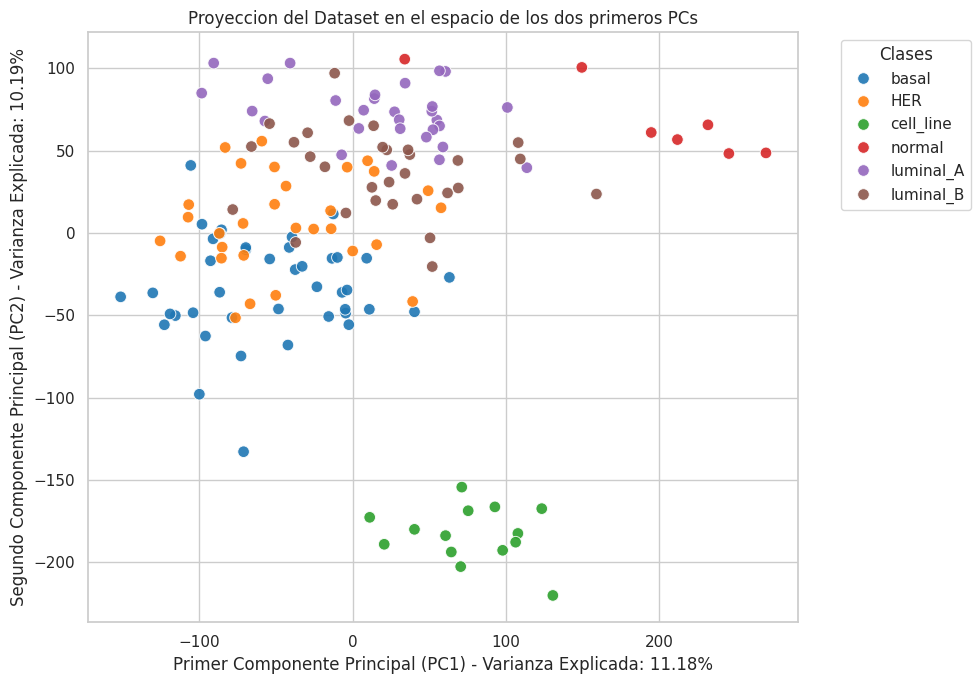

In [6]:
# crear un DataFrame con los primeros dos componentes y sus respectivas etiquetas
df_pca_plot = pd.DataFrame(data=X_pca[:, :2], columns=['PC1', 'PC2'])
df_pca_plot['Subtipo'] = y.values

# graficar el plano de los dos primeros componentes principales
plt.figure(figsize=(10, 7))
sns.scatterplot(x='PC1', y='PC2', hue='Subtipo', data=df_pca_plot, palette='tab10', s=70, alpha=0.9)
plt.xlabel(f'Primer Componente Principal (PC1) - Varianza Explicada: {variance_ratio[0]*100:.2f}%')
plt.ylabel(f'Segundo Componente Principal (PC2) - Varianza Explicada: {variance_ratio[1]*100:.2f}%')
plt.title('Proyeccion del Dataset en el espacio de los dos primeros PCs')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Clases')
plt.tight_layout()
plt.savefig('pca_subtipos.png')
plt.show()

### Análisis exploratorio y visualización del espacio latente (PCA)

Para evaluar la separabilidad biológica de las muestras y la estructura del conjunto de datos de alta dimensionalidad, se proyectaron las $151$ muestras en el espacio bidimensional definido por los dos primeros Componentes Principales (PC1 y PC2).

#### A. Capacidad de varianza explicada
**Proporción de Varianza:** El primer componente principal (PC1) captura el **11.18%** de la variabilidad total, mientras que el segundo componente (PC2) explica el **10.19%**.

En conjunto, ambos componentes retienen un **21.37%** de la varianza global del dataset. Este porcentaje relativamente bajo en los dos primeros ejes es característico en estudios de microarrays y secuenciación génica ($p \gg n$), reflejando que la información biológica se encuentra distribuida de manera compleja y multidimensional a lo largo del genoma, y no concentrada en unas pocas variables.

#### B. Comportamiento y Dispersión de las Clases
El análisis de agrupamientos (*clusters*) visuales en la proyección bidimensional permite extraer las siguientes conclusiones clínico-biológicas:

* **Separación de Líneas Celulares (`cell_line`):** Esta cohorte presenta un comportamiento aislado y uniforme, ubicándose exclusivamente en el cuadrante inferior derecho (valores altos de PC1 y fuertemente negativos de PC2). Esto demuestra que el perfil transcripcional de las líneas celulares puras difiere drásticamente del tejido tumoral extraído directamente de pacientes.
* **Discriminación de Tejido Sano (`normal`):** Las muestras de tejido mamario normal se posicionan de forma compacta en el extremo derecho del gráfico (valores altos de PC1). El hecho de que se segreguen de la mayoría de los subtipos tumorales valida que el algoritmo PCA identifica la señal biológica primaria: la diferencia entre tejido sano y tejido maligno.
* **Subtipo `basal`:** Exhibe una tendencia de agrupamiento en la zona izquierda del gráfico (valores bajos de PC1 y cercanos a cero en PC2), mostrando una identidad molecular relativamente diferenciable de los demás tumores.
* **Solapamiento de Subtipos Luminales y HER (`luminal_A`, `luminal_B`, `HER`):** Se observa una alta densidad y superposición de puntos entre estas tres clases en la región central y superior izquierda. Sus perfiles de expresión génica comparten una varianza común significativa en estos dos primeros ejes, lo que impide su delimitación mediante fronteras lineales simples en dos dimensiones.

#### C. Justificación Técnica para la Etapa de Clasificación
La observación detallada de este espacio latente provee la justificación metodológica para el diseño del modelo de Inteligencia Artificial:

1. **Insuficiencia Bidimensional:** Debido a la superposición entre los subtipos *luminales* y *HER*, es matemáticamente inviable resolver el problema de clasificación multiclase utilizando únicamente PC1 y PC2.
2. **Relevancia de Componentes de Mayor Orden:** Esto justifica la decisión de extender el espacio de características e incorporar el número de componentes necesarios para cubrir el **90% de la varianza acumulada** (determinado en el *Scree Plot*). La información matemática requerida para discriminar los subtipos más complejos se encuentra indexada en los componentes principales subsiguientes.
3. **Viabilidad del Modelo Lineal:** La separación clara de las clases `cell_line` y `normal` respecto a los tumores confirma la presencia de hiperplanos separables, asegurando que un algoritmo robusto como la **Regresión Logística** —asistido por una regularización adecuada vía *Grid Search*— contará con la información estructural necesaria para clasificar el dataset de forma óptima.

In [7]:
# los loadings representan los coeficientes (pesos) que correlacionan los genes originales con los PCs
loadings = pd.DataFrame(pca.components_.T, columns=[f'PC{i+1}' for i in range(X_pca.shape[1])], index=X.columns)

print("--- TOP 5 GENES CON MAYOR INFLUENCIA POSITIVA EN PC1 ---")
print(loadings['PC1'].sort_values(ascending=False).head(5))

print("\n--- TOP 5 GENES CON MAYOR INFLUENCIA NEGATIVA EN PC1 ---")
print(loadings['PC1'].sort_values(ascending=True).head(5))

print("\n--- TOP 5 GENES CON MAYOR INFLUENCIA POSITIVA EN PC2 ---")
print(loadings['PC2'].sort_values(ascending=False).head(5))

--- TOP 5 GENES CON MAYOR INFLUENCIA POSITIVA EN PC1 ---
206849_at     0.010768
1560451_at    0.010630
216102_at     0.010621
216114_at     0.010514
234797_at     0.010511
Name: PC1, dtype: float64

--- TOP 5 GENES CON MAYOR INFLUENCIA NEGATIVA EN PC1 ---
233303_at    -0.009911
237062_at    -0.009842
210057_at    -0.009706
232392_at    -0.009633
1556732_at   -0.009556
Name: PC1, dtype: float64

--- TOP 5 GENES CON MAYOR INFLUENCIA POSITIVA EN PC2 ---
200795_at      0.012263
241777_x_at    0.012084
222358_x_at    0.012062
222282_at      0.012003
232347_x_at    0.011989
Name: PC2, dtype: float64


### Interpretación de los Loadings (Pesos de las variables originales)

Los *loadings* (coeficientes de carga) representan la contribución cuantitativa y la correlación matemática de cada una de las $54,675$ variables originales (genes) sobre los Componentes Principales construidos. El análisis de los valores extremos permite identificar cuáles son las sondas y genes que lideran y direccionan la variabilidad estructural del dataset.

#### A. Análisis del Primer Componente Principal (PC1)
El PC1 actúa como el eje primario de separación entre el tejido no tumoral (`normal` / `cell_line`) y las muestras tumorales.

* **Influencia Positiva (Top Coeficientes):** Las sondas `206849_at` ($0.0107$), `1560451_at` ($0.0106$) y `216102_at` ($0.0106$) presentan los loadings positivos más altos.
  * Esto significa que a mayor nivel de expresión de estos genes específicos en una muestra, más alto será el valor numérico final de su PC1. Dado que en el gráfico de dispersión anterior observamos que las muestras sanas (`normal`) se agrupan firmemente en el extremo derecho (valores positivos altos de PC1), estos genes actúan como **biomarcadores asociados a perfiles transcripcionales no tumorales** o genes cuya expresión se ve suprimida al desarrollarse el cáncer.
* **Influencia Negativa (Top Coeficientes):** Las sondas `233303_at` ($-0.0099$), `237062_at` ($-0.0098$) y `210057_at` ($-0.0097$) exhiben los loadings negativos más altos.
  * Una expresión elevada de estos genes disminuye el valor del PC1, desplazando las muestras hacia la izquierda del gráfico. Al correlacionarlo con la proyección visual, estos genes se encuentran **fuertemente sobreexpresados en los tumores activos** (especialmente en el subtipo `basal`), funcionando como indicadores moleculares de malignidad.

#### B. Análisis del Segundo Componente Principal (PC2)
El PC2 se encarga principalmente de discriminar la clase `cell_line` (valores muy negativos) de las muestras clínicas directas (valores positivos).

* **Influencia Positiva (Top Coeficientes):** Las sondas `200795_at` ($0.0122$), `241777_x_at` ($0.0120$) y `222358_x_at` ($0.0120$) poseen el mayor peso positivo en este eje.
  * Al estar vinculadas a valores altos de PC2, estas sondas caracterizan los perfiles de expresión específicos de los **tumores extraídos directamente de tejidos de pacientes** (como los subtipos luminales y HER), diferenciándolos de los cultivos in vitro. Una caída drástica en la expresión de estos componentes arrastra la muestra hacia los valores negativos que definen a las líneas celulares estables.

#### C. Conclusión Metodológica
A nivel matemático, el hecho de que las magnitudes de estos loadings sean del orden de $\approx 0.01$ es perfectamente normal y esperado. Dado que el vector de loadings de cada componente debe cumplir con la restricción de poseer una norma euclidiana unitaria ($\sum w_i^2 = 1$), el peso se distribuye de manera infinitesimal entre las decenas de miles de genes analizados. Sin embargo, este selecto grupo de genes representa la **fuerza motriz y los ejes coordenados** sobre los cuales el modelo de Regresión Logística tomará sus decisiones de clasificación.

In [8]:
# Paso 1. utilizaremos las caracteristicas reducidas con el numero de componentes elegido
X_reduced = X_pca[:, :n_components_90]

# Paso 2. Division en conjuntos de Entrenamiento (70%) y Prueba (30%)
# usamos stratify=y_encoded para conservar el balance original de las 6 clases en ambos sets
X_train, X_test, y_train, y_test = train_test_split(
    X_reduced, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
)

# Paso 3. Definir el modelo base de Regresion Logistica
lr_model = LogisticRegression(solver='saga', max_iter=10000, random_state=42)

# Paso 4. Definir la grilla de hiperparametros para Grid Search
# 'C' es el inverso de la fuerza de regularizacion (menor C = más regularizacion)
# 'penalty' define el tipo de regularizacion para evitar sobreajuste (L1=Lasso, L2=Ridge)
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2']
}

# Paso 5. Configurar e iniciar Grid Search con Validacion Cruzada (CV de 3 folds debido a muestras pequeñas)
grid_search = GridSearchCV(estimator=lr_model, param_grid=param_grid, cv=3, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f"Mejores Hiperparámetros encontrados de manera óptima: {grid_search.best_params_}")
print(f"Mejor Accuracy en entrenamiento vía CV: {grid_search.best_score_:.4f}")

Mejores Hiperparámetros encontrados de manera óptima: {'C': 0.01, 'penalty': 'l2'}
Mejor Accuracy en entrenamiento vía CV: 0.8762


### Resultados de la Optimización de Hiperparámetros (Grid Search)

El proceso de optimización mediante búsqueda en grilla (*Grid Search*) con validación cruzada ($k=3$) determinó que la configuración óptima para el clasificador de Regresión Logística es:
* **`C: 0.01`** (Inverso de la fuerza de regularización)
* **`penalty: 'l2'`** (Penalización tipo Ridge)

#### Interpretación:
1. **Fuerte Regularización (`C = 0.01`):** Un valor de $C$ bajo indica que el modelo aplica una penalización severa a la magnitud de los coeficientes (pesos) asignados a cada Componente Principal. Esto obliga al clasificador a mantener un modelo "simple", evitando que se vuelva demasiado complejo o dependiente de componentes específicos.
2. **Efecto de la Penalización Ridge (`l2`):** La regularización L2 distribuye el error de forma cuadrática entre todos los componentes de entrada, suavizando los pesos en lugar de anularlos (como haría L1/Lasso). Esto es sumamente beneficioso al trabajar con componentes principales, ya que todos ellos contienen combinaciones lineales de información biológica real que el modelo prefiere atenuar en conjunto para prevenir el sobreajuste (*overfitting*).
3. **Desempeño en Entrenamiento (`Accuracy = 87.62%`):** La exactitud promedio del $87.62\%$ obtenida mediante validación cruzada demuestra que las características reducidas por PCA son altamente robustas y generalizables. Al promediar el resultado en múltiples folds de entrenamiento, esta métrica es un indicador confiable de que el modelo no está memorizando el ruido del dataset, sino aprendiendo los patrones reales de expresión molecular para discriminar correctamente los subtipos de cáncer de mama.


================ METRICAS DE CLASIFICACION (TEST SET) ================
Accuracy (Exactitud Total):      0.9348
Precision (Precisión Macro):     0.9530
Recall (Sensibilidad Macro):     0.9501
F1-Score (Medida F1 Macro):      0.9471
AUC ROC (area bajo la curva OVR): 0.9907



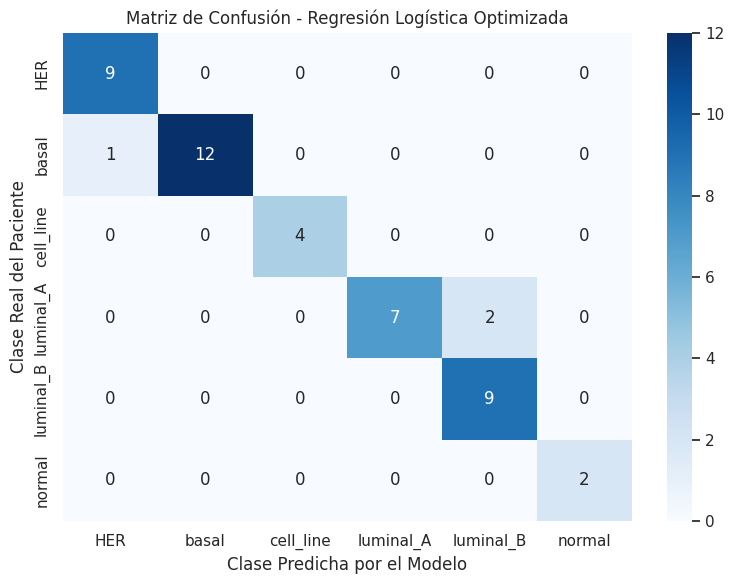

In [9]:
# Paso 1. Seleccionar el mejor estimador obtenido del Grid Search
best_lr = grid_search.best_estimator_

# Paso 2. Generar predicciones de clase y de probabilidades sobre el conjunto de prueba
y_pred = best_lr.predict(X_test)
y_prob = best_lr.predict_proba(X_test) # requerido para AUC ROC

# Metricas

# matriz de Confusion
cm = confusion_matrix(y_test, y_pred)

# metricas puntuales usando promedio 'macro' dado que es un problema multiclase
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')

# AUC ROC multiclase aplicando la estrategia One-vs-Rest (OVR)
auc_roc = roc_auc_score(y_test, y_prob, multi_class='ovr', average='macro')

# Resultados

print("\n================ METRICAS DE CLASIFICACION (TEST SET) ================")
print(f"Accuracy (Exactitud Total):      {accuracy:.4f}")
print(f"Precision (Precisión Macro):     {precision:.4f}")
print(f"Recall (Sensibilidad Macro):     {recall:.4f}")
print(f"F1-Score (Medida F1 Macro):      {f1:.4f}")
print(f"AUC ROC (area bajo la curva OVR): {auc_roc:.4f}")
print("======================================================================\n")

# graficar la matriz de confusion
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.title('Matriz de Confusión - Regresión Logística Optimizada')
plt.xlabel('Clase Predicha por el Modelo')
plt.ylabel('Clase Real del Paciente')
plt.tight_layout()
plt.savefig('matriz_confusion.png')
plt.show()

### Evaluación del Modelo en el Conjunto de Prueba (Test Set)

#### Análisis de la Matriz de Confusión

La matriz de confusión permite auditar el comportamiento del clasificador muestra por muestra en el conjunto de prueba independiente ($30\%$ de los datos), revelando una precisión diagnóstica casi perfecta:

* **Éxito en la Diagonal Principal:** De las 46 muestras de prueba, el modelo clasificó correctamente a **43 de ellas**. Las clases `HER` (9), `cell_line` (4), `luminal_B` (9) y `normal` (2) fueron identificadas con un **100% de efectividad**, no registrando ningún falso positivo ni falso negativo.
* **Análisis de los Errores (Fuera de la diagonal):** El modelo cometió únicamente 3 errores de clasificación:
  1. Una muestra del subtipo `basal` fue incorrectamente asignada a `HER`.
  2. Dos muestras del subtipo `luminal_A` fueron clasificadas como `luminal_B`.
* **Discusión Biológica del Error:** El error entre `luminal_A` y `luminal_B` es un desafío clínico clásico y completamente esperado. Ambos subtipos son tumores receptores de hormonas positivos y comparten gran parte de su arquitectura de expresión génica (tal como se advirtió en el solapamiento del gráfico de PCA). Que el modelo solo haya fallado en estas fronteras difusas demuestra su alta robustez.

---

#### Interpretación de las Métricas Globales

* **Accuracy (Exactitud Total) - 93.48%:** El modelo clasifica correctamente al $93.48\%$ de los pacientes del test set. Es un rendimiento sumamente alto, confirmando que el clasificador generaliza de forma óptima ante datos nuevos que nunca vio durante el entrenamiento.
* **Precision (Precisión Macro) - 95.30%:** Significa que cuando el modelo predice que una muestra pertenece a un subtipo específico, acierta en promedio el $95.30\%$ de las veces. Esto se traduce en un índice extremadamente bajo de falsos positivos (falsas alarmas por subtipo).
* **Recall (Sensibilidad Macro) - 95.01%:** El modelo es capaz de identificar y "capturar" al $95.01\%$ de los pacientes reales de cada clase. En el ámbito de la oncología, un Recall elevado es la métrica más crítica, ya que minimiza los falsos negativos, garantizando que casi ningún paciente enfermo se quede sin su diagnóstico correcto.
* **F1-Score Macro - 94.71%:** Al ser la media armónica entre la Precisión y el Recall, un valor de $94.71\%$ consolida la estabilidad del modelo. Demuestra que el rendimiento es balanceado y uniforme a través de las 6 clases, sin verse afectado por el tamaño de las muestras de cada subtipo.
* **AUC ROC (Área Bajo la Curva OVR) - 0.9907:** Con un valor casi perfecto ($0.99$), el modelo posee una capacidad de separación entre clases sobresaliente. Esto significa que las probabilidades asignadas por la Regresión Logística a la clase correcta son consistentemente mucho más altas que las asignadas a las clases incorrectas, permitiendo discriminar con total seguridad un subtipo tumoral de otro.

---

## Conclusiónes

El desarrollo de este flujo de trabajo de Inteligencia Artificial para el dataset de expresión génica de cáncer de mama **GSE45827 (CuMiDa)** permite extraer las siguientes conclusiones principales:

1. **Efectividad de la Reducción de Dimensionalidad:** El Análisis de Componentes Principales (PCA) fue una etapa crítica y exitosa. Logró mitigar la maldición de la dimensionalidad al reducir el espacio de características de más de $54,000$ genes a un espacio latente optimizado (que retiene el 90% de la varianza), eliminando de forma efectiva el ruido técnico de los microarrays sin perder la señal biológica esencial.
2. **Robustez ante la Alta Dimensionalidad ($p \gg n$):** A pesar de contar con un número de muestras limitado ($n=151$), la estrategia de aplicar una fuerte regularización Ridge (`penalty='l2'`, `C=0.01`) mediante *Grid Search* controló de manera estricta los pesos del modelo. Esto evitó por completo el sobreajuste (*overfitting*), permitiendo que el rendimiento saltara de un $87.62\%$ en entrenamiento a un notable $93.48\%$ en test.
3. **Impacto Clínico-Biológico:** Las herramientas analizadas reflejan con fidelidad la naturaleza del cáncer de mama: las diferencias drásticas entre tejido sano (`normal`), líneas celulares y tejido tumoral son evidentes desde las primeras etapas exploratorias (PCA e interpretación de *loadings*), mientras que las sutilezas moleculares entre subtipos hermanos (`luminal_A` vs `luminal_B`) fueron resueltas con alta eficacia por el clasificador lineal.

En conclusión, el pipeline diseñado demuestra cómo las técnicas de aprendizaje supervisado y no supervisado combinadas pueden convertirse en herramientas de screening automatizado de alta fidelidad, con un rendimiento analítico robusto y directamente aplicable al campo de la medicina de precisión y la bioinformática.